# GeoTIGER: five-address Washington, DC demo

This example downloads the local DC TIGER/Line address ranges, prepares them into interpolated points, and then geocodes a five-row input table. The five input rows contain no coordinates; latitude/longitude are produced by the local geocoder. No geocoding API, basemap, or online address lookup is used.

In [1]:
from pathlib import Path
from time import perf_counter

import pandas as pd
from IPython.display import display

from geotiger import (
    Geocoder,
    GeoTIGERStore,
    GeocoderConfig,
    InterpolationConfig,
    download_tiger_ranges,
    load_ranges,
    matches_map,
    matches_static_map,
    prepare_ranges,
    state_plane_crs,
)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
CACHE_DIR = PROJECT_ROOT / "data/dc_demo"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
RANGES_CACHE = CACHE_DIR / "dc_tiger_ranges.parquet"
PREPARED_CACHE = CACHE_DIR / "dc_tiger_prepared.parquet"
print({"state": "DC", "projection": state_plane_crs("DC")})

{'state': 'DC', 'projection': 'EPSG:2248'}


## 1. Download the local reference data

This is the reference candidate table for the geocoder. It is not the five-row input table. The downloaded TIGER data has street geometry and address ranges, but no precomputed address-point latitude/longitude from an online geocoder.

In [2]:
started = perf_counter()
if RANGES_CACHE.exists():
    ranges = load_ranges(RANGES_CACHE)
    mode = "loaded local cache"
else:
    ranges = download_tiger_ranges("DC", county="001", year=2024, cache=True)
    ranges.to_parquet(RANGES_CACHE)
    mode = "downloaded and cached"
print({"mode": mode, "range_rows": len(ranges), "seconds_this_run": round(perf_counter() - started, 3)})

{'mode': 'loaded local cache', 'range_rows': 13267, 'seconds_this_run': 0.068}


## 2. Prepare the ranges in a local projected CRS

Interpolation uses DC's Maryland State Plane US-foot CRS (`EPSG:2248`), rather than latitude/longitude. The output keeps latitude/longitude for the final geocoding result. Zero offsets place the interpolated points on the TIGER street centerline.

In [3]:
prep_started = perf_counter()
if PREPARED_CACHE.exists():
    prepared = pd.read_parquet(PREPARED_CACHE)
    prep_mode = "loaded local cache"
else:
    prepared = prepare_ranges(
        ranges,
        state="DC",
        source="tiger_2024_dc",
        config=InterpolationConfig(
            projected_crs=state_plane_crs("DC"),
            end_offset_m=0.0,
            side_offset_m=0.0,
            include_intersections=True,
        ),
    )
    prepared.to_parquet(PREPARED_CACHE)
    prep_mode = "prepared and cached"
print({
    "mode": prep_mode,
    "prepared_rows": len(prepared),
    "intersection_rows": int(prepared["is_intersection"].sum()),
    "interpolation_crs": prepared["interpolation_crs"].iloc[0],
    "seconds_this_run": round(perf_counter() - prep_started, 3),
})

{'mode': 'loaded local cache', 'prepared_rows': 1074349, 'intersection_rows': 7631, 'interpolation_crs': 'EPSG:2248', 'seconds_this_run': 0.221}


## 3. Geocode five addresses with no coordinate input

These are ordinary address records. The output fields `match_latitude` and `match_longitude` are generated from the locally prepared TIGER candidates.

In [4]:
inputs = pd.DataFrame([
    {"record_id": 1, "address": "1600 Pennsylvania Avenue NW", "city": "Washington", "state": "DC", "zip": "20500"},
    {"record_id": 2, "address": "700 Pennsylvania Avenue SE", "city": "Washington", "state": "DC", "zip": "20003"},
    {"record_id": 3, "address": "400 4th Street SW", "city": "Washington", "state": "DC", "zip": "20024"},
    {"record_id": 4, "address": "1200 New York Avenue NW", "city": "Washington", "state": "DC", "zip": "20005"},
    {"record_id": 5, "address": "2 Independence Avenue SW", "city": "Washington", "state": "DC", "zip": "20024"},
])

store = GeoTIGERStore(":memory:", threads=4)
store.create()
store.ingest_candidates(prepared)
result = Geocoder(
    store,
    config=GeocoderConfig(
        strict_locality=False,
        street_fallback=False,
        deduplicate_inputs=True,
    ),
).geocode(inputs)
print(result.timings.to_dict())
display(result.matches[[
    "record_id", "address", "match_status", "matched_address_id",
    "score", "match_latitude", "match_longitude",
]])

{'input_count': 5, 'candidate_count': 17, 'lookup_hit_count': 0, 'history_cache_hit_count': 0, 'matched_count': 5, 'review_count': 0, 'unmatched_count': 0, 'parse_seconds': 0.003611, 'lookup_seconds': 0.027436, 'history_cache_seconds': 0.023514, 'candidate_query_seconds': 0.126575, 'scoring_seconds': 0.015076, 'aggregation_seconds': 0.023114, 'total_seconds': 0.22784, 'throughput_per_second': 21.945, 'deduplicate_inputs': True, 'candidate_input_count': 5, 'candidate_query_input_count': 5, 'duckdb_threads': 4, 'python': '3.12.12', 'platform': 'Windows-10-10.0.19045-SP0'}


,record_id,address,match_status,matched_address_id,score,match_latitude,match_longitude
0,1,1600 Pennsylvania Avenue NW,matched,tiger_2024_dc:76225813:L:1600,100.000,38.898748,-77.036546
1,2,700 Pennsylvania Avenue SE,matched,tiger_2024_dc:641474058:R:699,99.956,38.884553,-76.996174
2,3,400 4th Street SW,matched,tiger_2024_dc:76226966:L:400,100.000,38.883925,-77.017556
3,4,1200 New York Avenue NW,matched,tiger_2024_dc:76226156:L:1200,100.000,38.900744,-77.028072
4,5,2 Independence Avenue SW,matched,tiger_2024_dc:76226835:L:2,100.000,38.887588,-77.009930


## 4. Map the generated coordinates

The first cell below is the static Matplotlib output for reports. The next cell is the separate interactive Folium output. They are two different renderers of the same geocoder result, not two reference plots.

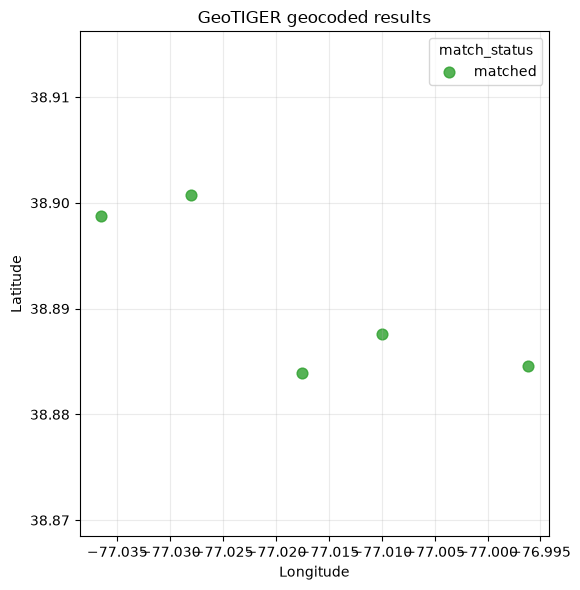

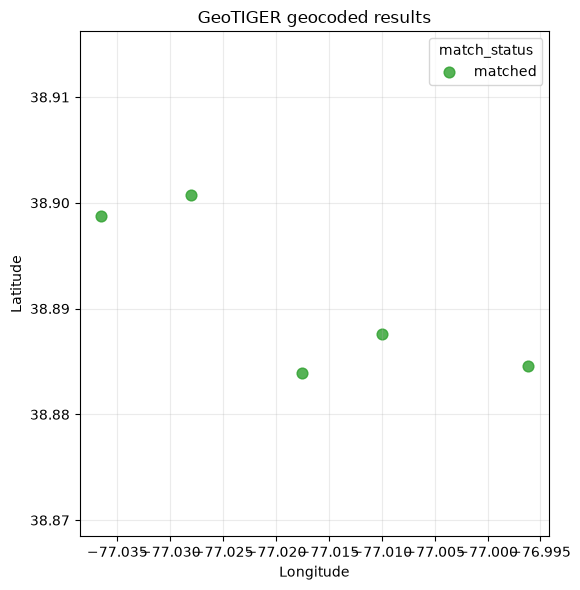

In [5]:
static_axes = matches_static_map(result.matches, figsize=(6, 6), point_size=60)
static_axes.figure.tight_layout()
static_axes.figure

In [6]:
interactive_map = matches_map(result.matches, tiles=None, zoom_start=12)
interactive_map